In [ ]:

import ast
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
plt.rcParams["font.family"] = "DejaVu Sans"

In [ ]:
def safe_literal_eval(cell) -> list:
    """Safely converts string representation of lists back to Python lists."""
    if pd.isna(cell):
        return []
    if isinstance(cell, list):
        return cell
    try:
        parsed = ast.literal_eval(str(cell))
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []


In [ ]:
def cap_review_text(text: str, max_len: int) -> str:
    """Caps a string at `max_len` characters."""
    text = str(text)
    return text[:max_len] if len(text) > max_len else text

print("=" * 70)
print("STEP 2: Outlier Detection & Handling (Review Length)")
print("=" * 70)

try:
    df = pd.read_csv("movie_reviews_step1_cleaned.csv")
except FileNotFoundError:
    print(f"\n[Error] Could not find 'movie_reviews_step1_cleaned.csv'")
    print("Make sure you have run Step 1 first!")
    exit(1)

STEP 2: Outlier Detection & Handling (Review Length)


In [ ]:
print(f"\n[Load]  Rows: {len(df):,}  |  Columns: {list(df.columns)}")


[Load]  Rows: 19,316  |  Columns: ['Unnamed: 0', 'Ratings', 'Reviews', 'movie_name', 'Resenhas', 'genres', 'Description', 'emotion', 'is_unknown_movie_name']


In [ ]:
df["genres"] = df["genres"].apply(safe_literal_eval)
print(f"[Parse] `genres` column restored to Python lists.")

df["review_length"] = df["Reviews"].astype(str).apply(len)


[Parse] `genres` column restored to Python lists.


In [ ]:
print(f"\n[Stats] Review Length (Characters):")
print(f"        Min : {df['review_length'].min():,}")
print(f"        Max : {df['review_length'].max():,}")
print(f"        Mean: {df['review_length'].mean():,.1f}")


[Stats] Review Length (Characters):
        Min : 49
        Max : 10,307
        Mean: 1,335.4


In [ ]:
length_before = df["review_length"].copy()


In [ ]:
Q1 = df["review_length"].quantile(0.25)
Q3 = df["review_length"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
is_length_outlier_before = (df["review_length"] < lower_bound) | (df["review_length"] > upper_bound)
n_outliers_before = is_length_outlier_before.sum()
pct_outliers_before = (n_outliers_before / len(df)) * 100

print(f"\n[IQR]   Bounds computed:")
print(f"        Lower: {lower_bound:,.0f}")
print(f"        Upper: {upper_bound:,.0f}")
print(f"[IQR]   Outliers flagged (Before): {n_outliers_before:,} ({pct_outliers_before:.2f}%)")



[IQR]   Bounds computed:
        Lower: -695
        Upper: 3,025
[IQR]   Outliers flagged (Before): 1,493 (7.73%)


In [ ]:
# Cap long reviews at the IQR upper bound instead of dropping.
# Dropping ~8% of rows would severely impact minority emotion/genre classes.

In [ ]:
upper_bound_int = int(upper_bound)
over_upper_mask = df["review_length"] > upper_bound

df.loc[over_upper_mask, "Reviews"] = df.loc[over_upper_mask, "Reviews"].apply(
    lambda t: cap_review_text(t, upper_bound_int)
)

df["review_length"] = df["Reviews"].astype(str).apply(len)


In [ ]:
is_length_outlier_after = (df["review_length"] < lower_bound) | (df["review_length"] > upper_bound)
n_outliers_after = is_length_outlier_after.sum()
pct_outliers_after = (n_outliers_after / len(df)) * 100

print(f"\n[Fix]   Capped {over_upper_mask.sum():,} long reviews at {upper_bound_int:,} characters.")
print(f"[IQR]   Outliers remaining (After) : {n_outliers_after:,} ({pct_outliers_after:.2f}%)")
if n_outliers_after > 0:
    print(f"        (These remaining outliers are extremely short reviews below the lower bound).")



[Fix]   Capped 1,493 long reviews at 3,025 characters.
[IQR]   Outliers remaining (After) : 0 (0.00%)


NameError: name 'CHART_FILE' is not defined

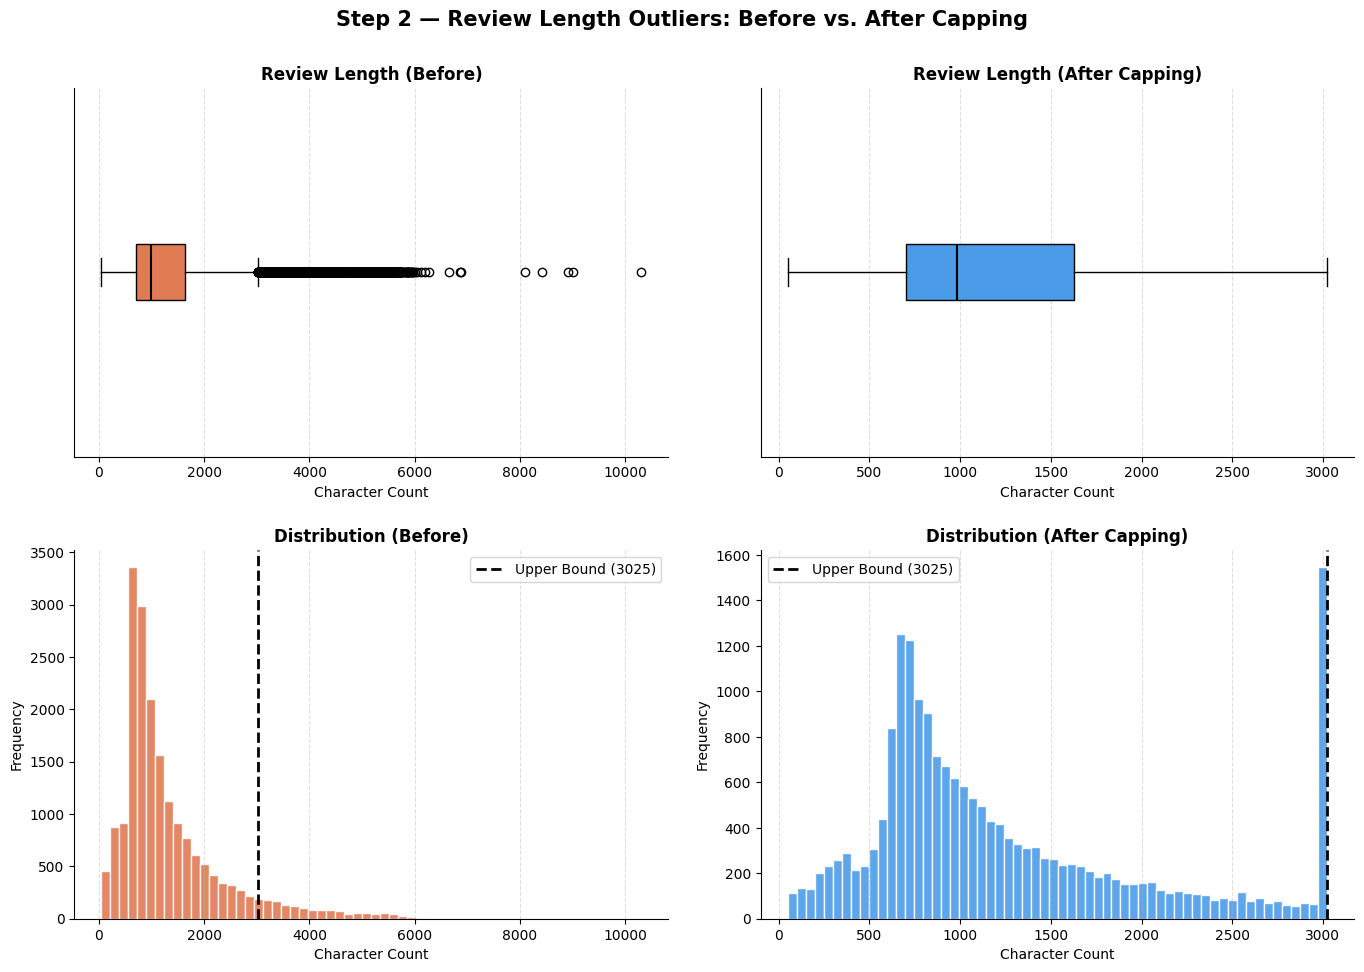

In [ ]:
COLORS_BEFORE = "#E07B54"  # warm orange
COLORS_AFTER  = "#4C9BE8"  # cool blue

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Step 2 — Review Length Outliers: Before vs. After Capping",
             fontsize=15, fontweight="bold", y=0.98)

axes[0, 0].boxplot(length_before, orientation="horizontal", patch_artist=True,
                   boxprops=dict(facecolor=COLORS_BEFORE, color='black'),
                   medianprops=dict(color='black', linewidth=1.5))
axes[0, 0].set_title("Review Length (Before)", fontweight="bold")
axes[0, 0].set_xlabel("Character Count")
axes[0, 0].set_yticks([])

axes[0, 1].boxplot(df["review_length"], orientation="horizontal", patch_artist=True,
                   boxprops=dict(facecolor=COLORS_AFTER, color='black'),
                   medianprops=dict(color='black', linewidth=1.5))
axes[0, 1].set_title("Review Length (After Capping)", fontweight="bold")
axes[0, 1].set_xlabel("Character Count")
axes[0, 1].set_yticks([])

axes[1, 0].hist(length_before, bins=60, color=COLORS_BEFORE, edgecolor='white', alpha=0.9)
axes[1, 0].axvline(upper_bound, color="black", linestyle="--", linewidth=2, label=f"Upper Bound ({upper_bound_int})")
axes[1, 0].set_title("Distribution (Before)", fontweight="bold")
axes[1, 0].set_xlabel("Character Count")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].legend()

axes[1, 1].hist(df["review_length"], bins=60, color=COLORS_AFTER, edgecolor='white', alpha=0.9)
axes[1, 1].axvline(upper_bound, color="black", linestyle="--", linewidth=2, label=f"Upper Bound ({upper_bound_int})")
axes[1, 1].set_title("Distribution (After Capping)", fontweight="bold")
axes[1, 1].set_xlabel("Character Count")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend()

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout(pad=2.0)
plt.savefig(CHART_FILE, dpi=150, bbox_inches="tight")
plt.close()
print(f"\n[Chart] Saved -> {CHART_FILE}")


In [ ]:
reviews_outliershandled = 'movies_reviews_step2_outliershandled.csv'

df["genres"] = df["genres"].apply(lambda g: str(g))

df.to_csv(reviews_outliershandled, index=False)
print(f"\n[Export] Saved -> {reviews_outliershandled}  ({len(df):,} rows)")
print("\n[Done]  Step 2 complete.\n")


[Export] Saved -> movies_reviews_step2_outliershandled.csv  (19,316 rows)

[Done]  Step 2 complete.

